In [1]:
import os
import sys
import glob
import uuid
import json
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

In [2]:
CONFIG = {
    "base_dir": r"Skin_cancer_dataset\dataset",
    "csv_name": "HAM10000_metadata.csv",
    "part1_dir": "HAM10000_images_part_1",
    "part2_dir": "HAM10000_images_part_2",
    "benign_dir": "benign",
    "model_name": "microsoft/swin-tiny-patch4-window7-224",
    "img_size": 224, 
    "batch_size": 8, 
    "test_size": 0.20,
    "head_lr": 1e-3,
    "fine_tune_lr": 1e-5,
    "head_epochs": 4,
    "fine_tune_epochs": 10,
    "weight_decay": 0.005,
    "seed": 42
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained(CONFIG["model_name"])

print(f"Setup Complete. Using device: {device}")

Setup Complete. Using device: cuda


In [3]:
csv_path = os.path.join(CONFIG["base_dir"], CONFIG["csv_name"])
part1_paths = glob.glob(os.path.join(CONFIG["base_dir"], CONFIG["part1_dir"], "*.jpg"))
part2_paths = glob.glob(os.path.join(CONFIG["base_dir"], CONFIG["part2_dir"], "*.jpg"))
image_path_map = {os.path.splitext(os.path.basename(p))[0]: p for p in part1_paths + part2_paths}

df = pd.read_csv(csv_path)
df['path'] = df['image_id'].map(image_path_map)
df = df.dropna(subset=['path']).reset_index(drop=True)

lesion_dict = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis', 
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratoses', 
    'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_dict)

benign_paths = glob.glob(os.path.join(CONFIG["base_dir"], CONFIG["benign_dir"], "*.*"))
df_benign = pd.DataFrame({
    'image_id': [f"benign_{i}" for i in range(len(benign_paths))],
    'dx': 'none',
    'lesion_id': [str(uuid.uuid4()) for _ in range(len(benign_paths))],
    'path': benign_paths,
    'cell_type': 'Not a Lesion'
})

df_combined = pd.concat([df, df_benign], ignore_index=True)
df_combined['label'] = pd.Categorical(df_combined['cell_type']).codes
class_names = list(pd.Categorical(df_combined['cell_type']).categories)

unique_lesions = df_combined['lesion_id'].unique()
train_lesions, val_lesions = train_test_split(unique_lesions, test_size=CONFIG["test_size"], random_state=CONFIG["seed"])

train_df = df_combined[df_combined['lesion_id'].isin(train_lesions)].reset_index(drop=True)
val_df = df_combined[df_combined['lesion_id'].isin(val_lesions)].reset_index(drop=True)

print(f"Data Processed. Classes: {class_names}")

Data Processed. Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevi', 'Melanoma', 'Not a Lesion', 'Vascular lesions']


In [4]:
print(f"Original Training Dataset Size: {len(train_df)}")

new_dfs = []
for class_label in train_df['label'].unique():
    class_df = train_df[train_df['label'] == class_label]
    class_name = class_names[class_label]
    
    if class_name in ['Melanoma', 'Benign keratosis']:
        extra_half = class_df.sample(frac=0.5, random_state=CONFIG["seed"])
        new_dfs.extend([class_df, extra_half])
    elif class_name in ['Basal cell carcinoma', 'Actinic keratoses', 'Vascular lesions', 'Dermatofibroma']:
        new_dfs.append(pd.concat([class_df] * 4, ignore_index=True))
    else: 
        new_dfs.append(class_df)

train_df_balanced = pd.concat(new_dfs, ignore_index=True).sample(frac=1.0, random_state=CONFIG["seed"]).reset_index(drop=True)
print(f"New Balanced Training Dataset Size: {len(train_df_balanced)}")

medical_augmentations = transforms.Compose([
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5)
])

Original Training Dataset Size: 13642
New Balanced Training Dataset Size: 17086


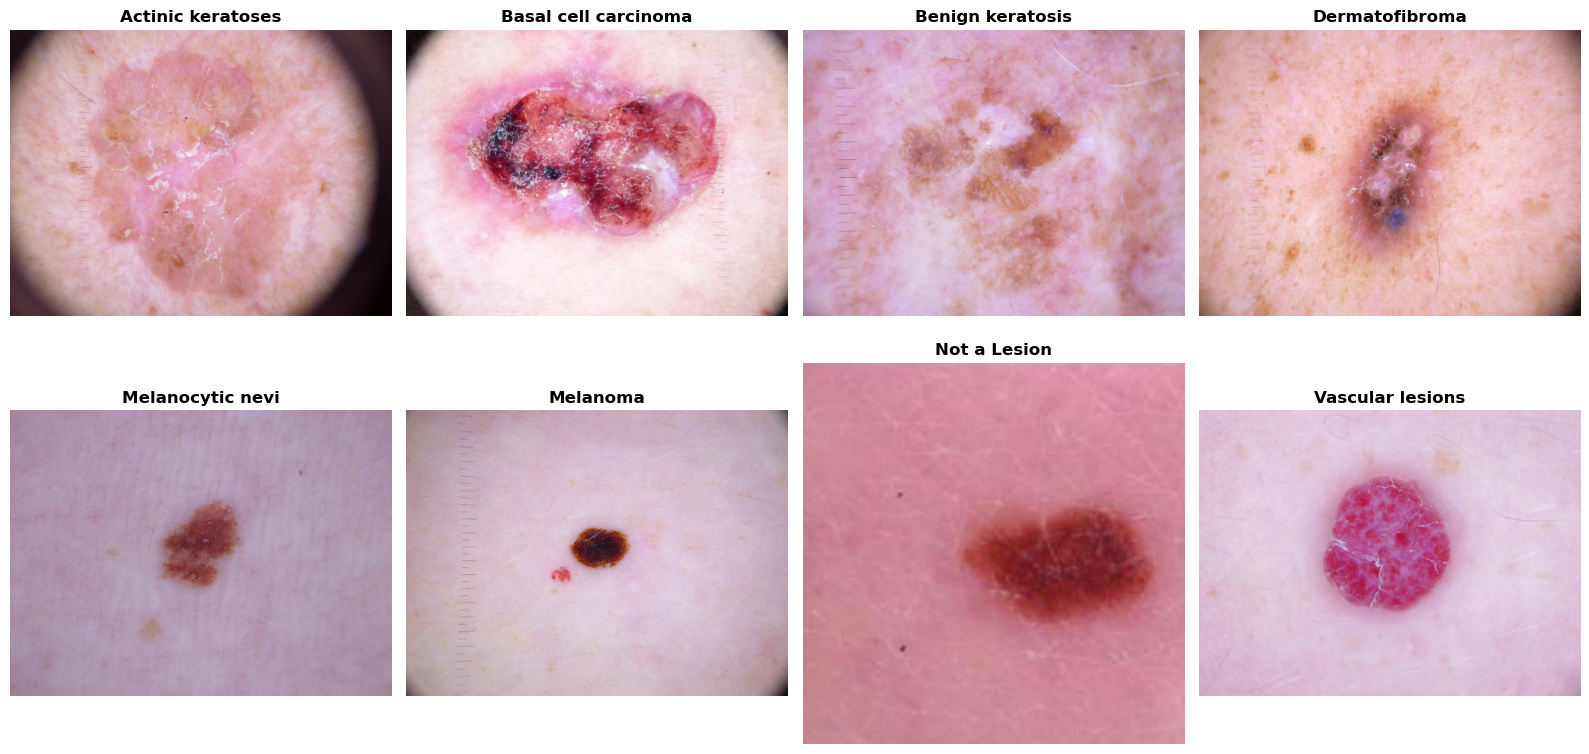

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    sample_path = df_combined[df_combined['cell_type'] == class_name].iloc[0]['path']
    img = Image.open(sample_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
class SkinCancerDataset(Dataset):
    def __init__(self, df, processor, img_size, transform=None):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.img_size = img_size
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        inputs = self.processor(
            images=image, 
            return_tensors="pt",
            size={"height": self.img_size, "width": self.img_size} 
        )
        return inputs['pixel_values'].squeeze(0), torch.tensor(label, dtype=torch.long)

train_dataset = SkinCancerDataset(train_df_balanced, processor, CONFIG["img_size"], transform=medical_augmentations)
val_dataset = SkinCancerDataset(val_df, processor, CONFIG["img_size"], transform=None)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

print(f"DataLoaders Ready. Training Batches: {len(train_loader)} | Validation Batches: {len(val_loader)}")

DataLoaders Ready. Training Batches: 2136 | Validation Batches: 423


In [7]:
class ViTClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        in_features = self.backbone.config.hidden_size
        
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        features = outputs.pooler_output if hasattr(outputs, 'pooler_output') else outputs.last_hidden_state[:, 0, :]
        return self.head(features)

model = ViTClassifier(CONFIG["model_name"], len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

def execute_epoch(model, loader, criterion, optimizer=None, scaler=None, is_train=True):
    model.train() if is_train else model.eval()
    running_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    
    with context:
        pbar = tqdm(loader, total=len(loader), desc="Train" if is_train else "Val", leave=True, position=0, file=sys.stdout)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            if is_train: optimizer.zero_grad()
                
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{correct/total:.4f}"})
            
    return running_loss / total, correct / total

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

[transformers] SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
print("--- PHASE 1: WARMING UP CLASSIFIER HEAD ---")
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer_head = torch.optim.AdamW(model.head.parameters(), lr=CONFIG["head_lr"], weight_decay=CONFIG["weight_decay"])
best_val_acc = 0.0

for epoch in range(1, CONFIG["head_epochs"] + 1):
    t_loss, t_acc = execute_epoch(model, train_loader, criterion, optimizer_head, scaler, is_train=True)
    v_loss, v_acc = execute_epoch(model, val_loader, criterion, is_train=False)
    
    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc); history["val_acc"].append(v_acc)
    print(f"Phase 1 - Epoch {epoch}/{CONFIG['head_epochs']} | T-Loss: {t_loss:.4f} | T-Acc: {t_acc:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_acc:.4f}")

--- PHASE 1: WARMING UP CLASSIFIER HEAD ---
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:23<00:00,  5.07it/s, loss=0.0013, acc=0.8375]
Phase 1 - Epoch 1/4 | T-Loss: 0.7555 | T-Acc: 0.7284 | V-Loss: 0.4405 | V-Acc: 0.8375
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:26<00:00,  4.88it/s, loss=0.0000, acc=0.8354]
Phase 1 - Epoch 2/4 | T-Loss: 0.6291 | T-Acc: 0.7728 | V-Loss: 0.4548 | V-Acc: 0.8354
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:23<00:00,  5.09it/s, loss=0.0000, acc=0.8413]
Phase 1 - Epoch 3/4 | T-Loss: 0.5964 | T-Acc: 0.7814 | V-Loss: 0.4243 | V-Acc: 0.8413
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:05<00:00,  6.48it/s, loss=0.0000, acc=0.8475]
Phase 1 - Epoch 4/4 | T-Loss: 0.5729 | T-Acc: 0.7923 | V-Loss: 0.4206 | V-Acc: 0.8475


In [9]:
print("\n--- PHASE 2: FULL NETWORK FINE-TUNING ---")
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer_full = torch.optim.AdamW(model.parameters(), lr=CONFIG["fine_tune_lr"], weight_decay=CONFIG["weight_decay"])

for epoch in range(1, CONFIG["fine_tune_epochs"] + 1):
    t_loss, t_acc = execute_epoch(model, train_loader, criterion, optimizer_full, scaler, is_train=True)
    v_loss, v_acc = execute_epoch(model, val_loader, criterion, is_train=False)
    
    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc); history["val_acc"].append(v_acc)
    print(f"Phase 2 - Epoch {epoch}/{CONFIG['fine_tune_epochs']} | T-Loss: {t_loss:.4f} | T-Acc: {t_acc:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_acc:.4f}")
    
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "best_training_weights.pth")


--- PHASE 2: FULL NETWORK FINE-TUNING ---
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:02<00:00,  6.75it/s, loss=0.0000, acc=0.8887]
Phase 2 - Epoch 1/10 | T-Loss: 0.4174 | T-Acc: 0.8479 | V-Loss: 0.3187 | V-Acc: 0.8887
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:24<00:00,  4.98it/s, loss=0.0000, acc=0.8958]
Phase 2 - Epoch 2/10 | T-Loss: 0.2973 | T-Acc: 0.8901 | V-Loss: 0.3122 | V-Acc: 0.8958
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:17<00:00,  5.44it/s, loss=0.0000, acc=0.8979]
Phase 2 - Epoch 3/10 | T-Loss: 0.2371 | T-Acc: 0.9154 | V-Loss: 0.3158 | V-Acc: 0.8979
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:07<00:00,  6.22it/s, loss=0.0000, acc=0.9026]
Phase 2 - Epoch 4/10 | T-Loss: 0.1805 | T-Acc: 0.9340 | V-Loss: 0.3016 | V-Acc: 0.9026
Val: 100%|██████████████████████████████████████████████████| 423/423 [01:22<00:00,  5.14it/s, loss=0.0000, acc=0.9014]
Phase 2 -

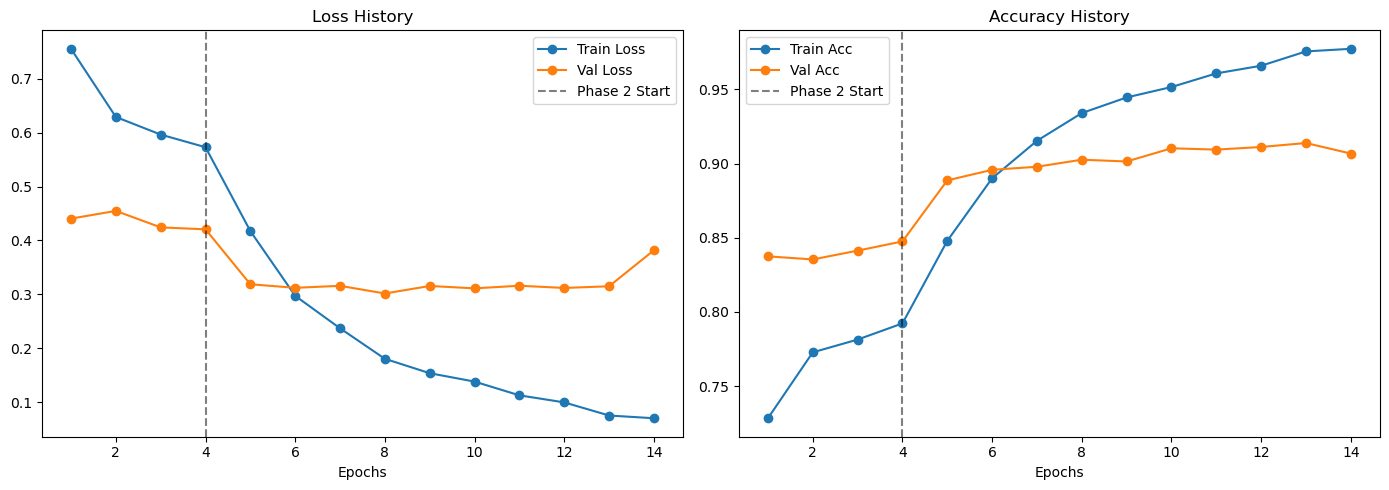

In [10]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history["train_loss"], label='Train Loss', marker='o')
ax1.plot(epochs_range, history["val_loss"], label='Val Loss', marker='o')
ax1.axvline(x=CONFIG["head_epochs"], color='black', linestyle='--', alpha=0.5, label='Phase 2 Start')
ax1.set_title('Loss History')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label='Train Acc', marker='o')
ax2.plot(epochs_range, history["val_acc"], label='Val Acc', marker='o')
ax2.axvline(x=CONFIG["head_epochs"], color='black', linestyle='--', alpha=0.5, label='Phase 2 Start')
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.tight_layout()
plt.show()

Generating Predictions: 100%|████████████████████████████████████████████████████████| 423/423 [01:08<00:00,  6.15it/s]


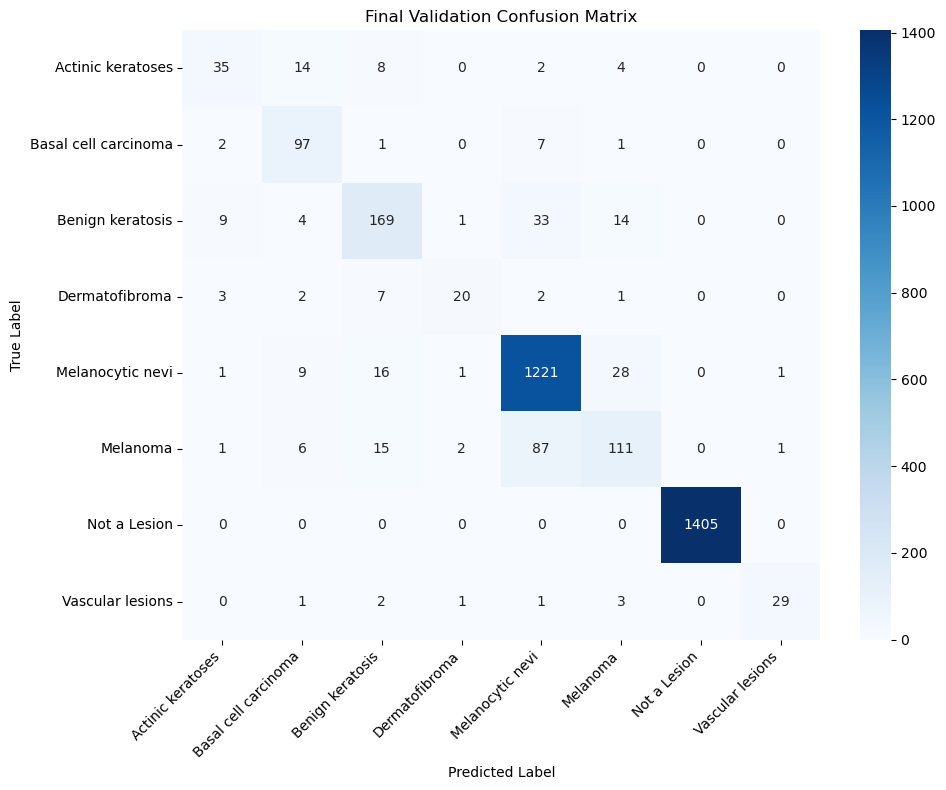


--- CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

   Actinic keratoses       0.69      0.56      0.61        63
Basal cell carcinoma       0.73      0.90      0.80       108
    Benign keratosis       0.78      0.73      0.75       230
      Dermatofibroma       0.80      0.57      0.67        35
    Melanocytic nevi       0.90      0.96      0.93      1277
            Melanoma       0.69      0.50      0.58       223
        Not a Lesion       1.00      1.00      1.00      1405
    Vascular lesions       0.94      0.78      0.85        37

            accuracy                           0.91      3378
           macro avg       0.81      0.75      0.77      3378
        weighted avg       0.91      0.91      0.91      3378



In [11]:
model.load_state_dict(torch.load("best_training_weights.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Generating Predictions"):
        images = images.to(device)
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Final Validation Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

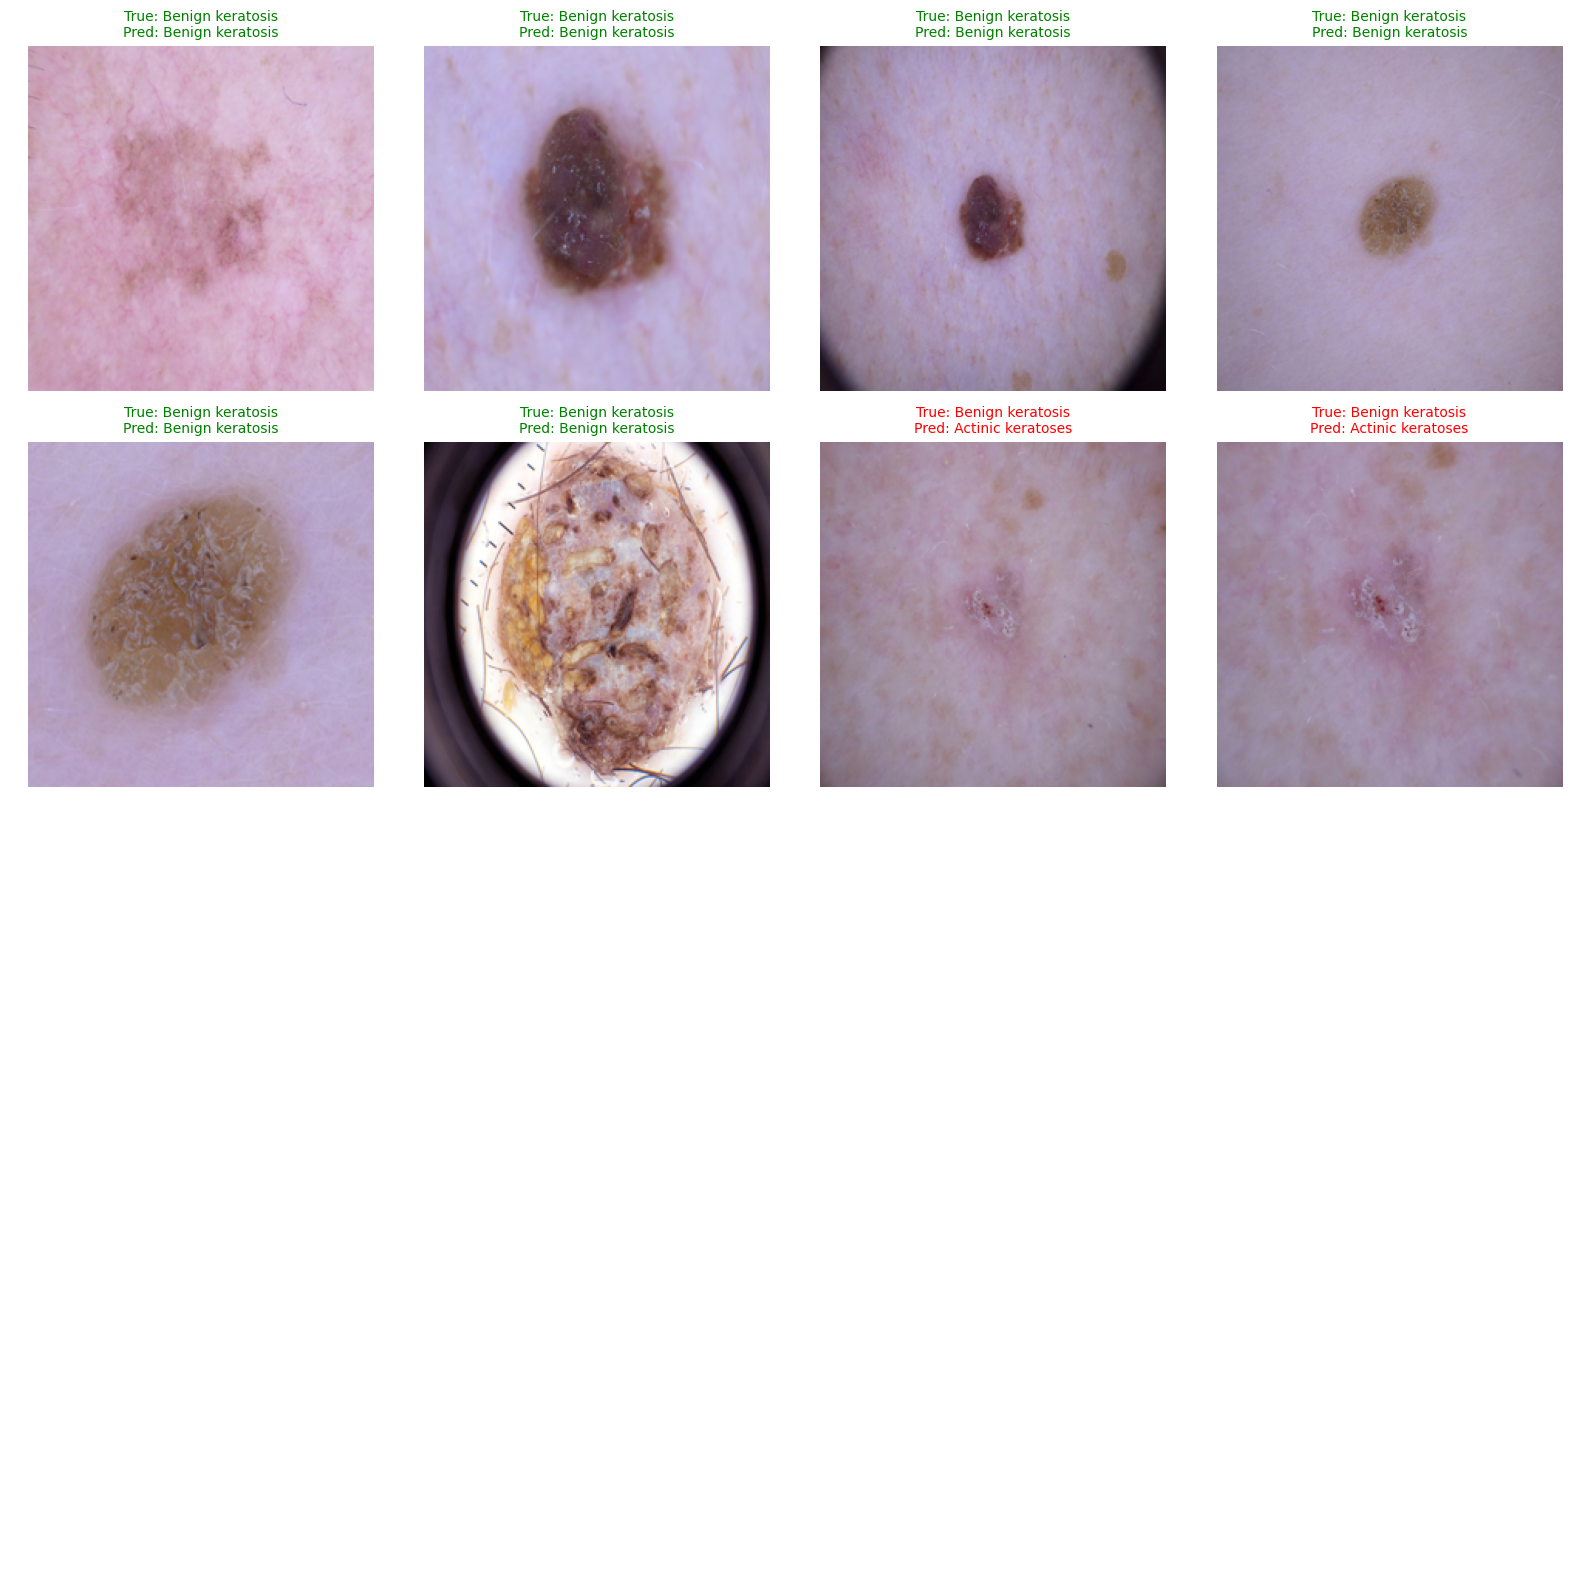

In [12]:
pixel_mean = torch.tensor(processor.image_mean).view(3, 1, 1)
pixel_std = torch.tensor(processor.image_std).view(3, 1, 1)

batch_images, batch_labels = next(iter(val_loader))

model.eval()
with torch.no_grad():
    outputs = model(batch_images.to(device))
    _, batch_preds = torch.max(outputs, 1)

batch_preds = batch_preds.cpu()

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i in range(16):
    if i < len(batch_images):
        img = batch_images[i] * pixel_std + pixel_mean
        img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()
        
        true_label = class_names[batch_labels[i].item()]
        pred_label = class_names[batch_preds[i].item()]
        
        title_color = 'green' if true_label == pred_label else 'red'
        
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10, color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [13]:
import pickle

torch.save(model.state_dict(), "model_weights.pth")

with open("model_deployment.pkl", "wb") as f:
    pickle.dump(model, f)

class_mapping = {i: name for i, name in enumerate(class_names)}
with open("classes.json", "w") as f:
    json.dump(class_mapping, f, indent=4)

print("Deployment artifacts successfully generated.")
print("- model_weights.pth")
print("- model_deployment.pkl")
print("- classes.json")

Deployment artifacts successfully generated.
- model_weights.pth
- model_deployment.pkl
- classes.json
